In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from itertools import product
import heapq

# automatically updates and reloads the imported functions from my own modules
%load_ext autoreload
%autoreload 2
    
import fourier_funcs
import Epower_funcs

In [2]:
def comm(A,B):
    return A@B-B@A

def antisym_3_bra(X):
    assert X.shape == (2*P,2*P,2*P,2*P,2*P,2*P)
    return 1/6*( X 
              -np.einsum('abcijk->abcikj',X) 
              -np.einsum('abcijk->abcjik',X) 
              +np.einsum('abcijk->abcjki',X) 
              +np.einsum('abcijk->abckij',X) 
              -np.einsum('abcijk->abckji',X)  )

def antisym_3_ket(X):
    return 1/6*( X 
                -np.einsum('abcijk->acbijk',X) 
                -np.einsum('abcijk->bacijk',X) 
                +np.einsum('abcijk->bcaijk',X) 
                +np.einsum('abcijk->cabijk',X) 
                -np.einsum('abcijk->cbaijk',X) )

def antisym_3_full(X):
    return antisym_3_ket(antisym_3_bra(X))   # bra then ket (order doesn't matter, they commute)

def antisym_3_full_t(X):
    antisym = []
    for t in range(X.shape[-1]):
        antisym.append(antisym_3_ket(antisym_3_bra(X[:,:,:,:,:,:,t])))
    antisym = np.array(antisym)
    antisym = np.einsum('tijklmn->ijklmnt',antisym)
    return antisym   # bra then ket (order doesn't matter, they commute)

def Hh0():
    h0 = np.zeros((2*P,2*P),dtype=complex)
    for i in range(-P,P):
        if i==0:
            h0[i+P,i+P] = eps/2 * 1
        else:
            h0[i+P,i+P] = eps/2 * np.sign(i)
    return h0

def Hv():
    v = np.zeros((2*P,2*P,2*P,2*P),dtype=complex)
    for i in range(P): # 0,1,2
        for j in range(P):
            
            v[i+P, j+P, i, j] = -V
            v[i, j, i+P, j+P] = -V
    v = v.reshape(4*P**2,4*P**2)
    return v
    
def TDHF(t,y):
    rho = y.reshape(2*P,2*P)
    d_rho = np.zeros_like(rho,dtype=complex)

    h0 = Hh0()
    v = Hv()

    d_rho += comm(h0,rho)
    
    rhorho = np.kron(rho,rho).reshape(2*P,2*P,2*P,2*P) # axis 0,2 is particle 1, axis 1,3 is particle 2. 
    # now make the antisymmetrised 2body density
    arho12 = ( rhorho - np.einsum('ijkl->ijlk',rhorho) ).reshape(4*P**2,4*P**2) # swap second axis of the two particles ie axes 2 and 3
    
    comm2 = comm(v,arho12)
    tr2 = np.einsum('ijkj->ik', comm2.reshape(2*P,2*P,2*P,2*P))
    d_rho += tr2

    d_rho = -1j*d_rho
    return d_rho.ravel()

def tdhf_terms(rho):
    termh0 = comm(Hh0(),rho)
    rhorho = np.kron(rho,rho).reshape(2*P,2*P,2*P,2*P) # axis 0,2 is particle 1, axis 1,3 is particle 2. 
    arho12 = ( rhorho - np.einsum('ijkl->ijlk',rhorho) ).reshape(4*P**2,4*P**2) # swap second axis of the two particles ie axes 2 and 3
    comm2 = comm(Hv(),arho12)
    termv = np.einsum('ijkj->ik', comm2.reshape(2*P,2*P,2*P,2*P))
    return termh0, termv
    

# """
# XXX FROM HERE 
# """
# def rho3_uncorrelated(rho):
#     """
#     A_(3) S_(3) [rho(1) rho(2) rho(3)].

#     Output indices:
#         out[i,j,k,l,m,n] = rho3(ijk,lmn)

#     This is the determinant-like three-body density, with exactly
#     six distinct terms and no normalization prefactor.
#     """
#     return (
#         + np.einsum('il,jm,kn->ijklmn', rho, rho, rho)
#         - np.einsum('il,jn,km->ijklmn', rho, rho, rho)
#         - np.einsum('im,jl,kn->ijklmn', rho, rho, rho)
#         + np.einsum('im,jn,kl->ijklmn', rho, rho, rho)
#         + np.einsum('in,jl,km->ijklmn', rho, rho, rho)
#         - np.einsum('in,jm,kl->ijklmn', rho, rho, rho)
#     )
# def rho_c2_unique(rho, c2):
#     """
#     A_(3) S_(3) [rho c2], with the nine distinct terms of
#     Eq. (2.11) in the paper.

#     rho[i,l]       = rho(i,l)
#     c2[i,j,l,m]    = c2(ij,lm)

#     Output:
#         out[i,j,k,l,m,n] = out(ijk,lmn)
#     """
#     return (
#         # Three direct cluster placements
#         + np.einsum('il,jkmn->ijklmn', rho, c2)  # rho(1) c2(23)
#         + np.einsum('jm,ikln->ijklmn', rho, c2)  # rho(2) c2(13)
#         + np.einsum('kn,ijlm->ijklmn', rho, c2)  # rho(3) c2(12)

#         # Six exchange terms
#         - np.einsum('im,jkln->ijklmn', rho, c2)
#         - np.einsum('jl,ikmn->ijklmn', rho, c2)
#         - np.einsum('kl,ijnm->ijklmn', rho, c2)

#         - np.einsum('in,jkml->ijklmn', rho, c2)
#         - np.einsum('jn,iklm->ijklmn', rho, c2)
#         - np.einsum('km,ijln->ijklmn', rho, c2)
#     )
# """
# XXX TO HERE 
# """


def TDDM(t,y):
    rho = y[:2*P*2*P].reshape(2*P,2*P)
    c = y[2*P*2*P:].reshape(4*P**2,4*P**2)

    d_rho = np.zeros_like(rho,dtype=complex)
    d_c = np.zeros_like(c,dtype=complex)

    h0 = Hh0()
    v = Hv()
    
    # full hamiltonian, is 2body: 
    H2 = np.kron(h0, np.eye(2*P,dtype=complex)) + np.kron(np.eye(2*P,dtype=complex), h0) + v

    # first the equation for d_rho:
    d_rho += comm(h0,rho)
    
    rhorho = np.kron(rho,rho).reshape(2*P,2*P,2*P,2*P) # axis 0,2 is particle 1, axis 1,3 is particle 2. 
    # now make the antisymmetrised 2body density:
    arho12 = rhorho - np.einsum('abcd->abdc',rhorho) # swap second axis of the two particles
    arho12 = arho12.reshape(4*P**2,4*P**2)
    
    # now the commutator: 
    comm2 = comm(v, arho12 + c)
    tr2 = np.trace(comm2.reshape(2*P,2*P,2*P,2*P), axis1=1, axis2=3) 
    d_rho += tr2 # ends up shape (2P,2P)

    
    # now the equation for d_c: (using full expression without cancelling unlinked terms)
    d_c += comm(H2, arho12 + c) # shape (4P^2,4P^2)
    
    # trace over particle 3 term:
    # first build the 3body components 
    rhorhorho = np.kron(np.kron(rho,rho),rho).reshape(2*P,2*P,2*P,2*P,2*P,2*P)
    arhorhorho = antisym_3_full(rhorhorho)
    
    rhoc = np.einsum('il,jkmn->ijklmn', rho, c.reshape(2*P,2*P,2*P,2*P) ) #i1 j2 k3 l1 m2 n3 
    arhoc = antisym_3_full(rhoc)
    # these all produced identical terms after the antisymmetrisation
    # rho2c13 = np.einsum('jm,ikln->ijklmn', rho, c.reshape(2*P,2*P,2*P,2*P) )
    # arho2c13 = antisym_3_full(rho2c13)
    # rho3c12 = np.einsum('kn,ijlm->ijklmn', rho, c.reshape(2*P,2*P,2*P,2*P) )
    # arho3c12 = antisym_3_full(rho3c12)
    
    all3 = 6.0*arhorhorho + 9.0*arhoc # arho1c23 + arho2c13 + arho3c12

    # """ XXX HERE """
    # c4 = c.reshape(2*P, 2*P, 2*P, 2*P)
    # all3chat = rho3_uncorrelated(rho) + rho_c2_unique(rho, c4)

    # print('difference 3body constructions: ',np.max(np.abs(all3chat - all3)) )
    # """ XXX HERE """

    v13 = np.einsum('ikln,jm->ijklmn', v.reshape(2*P,2*P,2*P,2*P), np.eye((2*P),dtype=complex))
    v23 = np.einsum('jkmn,il->ijklmn', v.reshape(2*P,2*P,2*P,2*P), np.eye((2*P),dtype=complex))
    comm3 = comm( v13.reshape(8*P**3,8*P**3) + v23.reshape(8*P**3,8*P**3), all3.reshape(8*P**3,8*P**3) )
    comm3 = comm3.reshape(2*P,2*P,2*P,2*P,2*P,2*P)
    tr3 = np.einsum('ijklmk->ijlm',comm3) # shape (2*P,2*P,2*P,2*P)
    d_c += tr3.reshape(4*P**2,4*P**2) 

    # note, d_rho is currently still i*d_rho 
    d_c -= np.einsum('ik,jl->ijkl',d_rho,rho).reshape(4*P**2,4*P**2) 
    d_c += np.einsum('ik,jl->ijlk',d_rho,rho).reshape(4*P**2,4*P**2) # antisym of the above term
    d_c -= np.einsum('jl,ik->ijkl',d_rho,rho).reshape(4*P**2,4*P**2) 
    d_c += np.einsum('jl,ik->ijlk',d_rho,rho).reshape(4*P**2,4*P**2) # antisym of the above term

    # now account for the factor of i, and reshape + combine them all
    d_rho = -1j*d_rho
    d_c = -1j*d_c

    return np.concatenate(( d_rho.ravel(),d_c.ravel() ))


''' Observables: '''

# def Ndown(rho):
#     down = np.zeros((2*P,2*P),dtype=complex)
#     for i in range(P):
#         down[i,i] = 1
#     return np.trace(np.einsum("ijt,jk->ikt",rho,down), axis1=0,axis2=1)

def Ndown(rho):
    assert rho.shape[:2]==(2*P,2*P)
    assert rho.ndim==3
    yep = np.array([1,1,1,0,0,0])
    down = np.outer(yep,yep)
    return np.einsum('ijt,ji->t',rho,down)

# def Nup(rho):
#     up = np.zeros((2*P,2*P),dtype=complex)
#     for i in range(P,2*P):
#         up[i,i] = 1
#     return np.trace(np.einsum("ijt,jk->ikt",rho,up), axis1=0,axis2=1)

def Nup(rho):
    assert rho.shape[:2]==(2*P,2*P)
    assert rho.ndim==3
    yep = np.array([0,0,0,1,1,1])
    up = np.outer(yep,yep)
    return np.einsum('ijt,ji->t',rho,up)

def HFstatD(D,th,phi):
    # this is the observable for how much of the state D is in the HF stationary state determined by theta and phi
    if D.shape[:2] == ((2*P)**P,(2*P)**P):
        D = D.reshape(2*P,2*P,2*P,2*P,2*P,2*P, -1)
    if D.shape[:6] != (2 * P,) * 6: 
        raise AttributeError("fix shape of density matrix")
    p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
    p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
    p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)
    psiin = np.einsum('i,j,k->ijk',p1,p2,p3)
    slat = 1/np.sqrt(6)*( psiin 
              -np.einsum('ijk->ikj',psiin)
              -np.einsum('ijk->jik',psiin)
              +np.einsum('ijk->jki',psiin)
              +np.einsum('ijk->kij',psiin)
              -np.einsum('ijk->kji',psiin)  )
    ex = np.einsum('ijk,ijklmnt,lmn->t', slat.conj(), D, slat)
    return ex

def HFstat(rho,th,phi):
    # this is the observable for how much of the state rho is in the HF stationary state determined by theta and phi
    # do Tr(rho |min><min|)
    assert rho.shape[:2] == (2*P,2*P) # ie the 1body rho
    static = np.zeros(2*P,dtype=complex)
    for i in range(P):
        static[i] = np.cos(th/2)
        static[i+P] = np.exp(-1j*phi)*np.sin(th/2)
    observ = np.outer(static,static.conj())
    if rho.ndim==2:
        trace = np.einsum('ij,ji->',rho,observ)
    if rho.ndim==3:
        trace = np.einsum('ijt,ji->t',rho,observ)
    return trace



def build_rho2(n, c2):
    """rho2[a,b,a',b'] = <c+_a' c+_b' c_b c_a> = A(nn) + C2."""
    Ann = (np.einsum('act,bdt->abcdt', n, n)
         - np.einsum('adt,bct->abcdt', n, n))
    return Ann + c2


def lower_occupation(n, c2, N=None):
    """
    Particles in the bottom level, for index ordering
    (-1..-P, +1..+P)  ->  lower block is 0:P.

    Returns mean, variance, and the trace-relation residual.
    """
    if N is None:
        N = P                                  # particle number
    lo = slice(0, P)

    # --- mean: one-body only ---
    mean = np.einsum('aat->t', n[lo, lo,:]).real

    # --- variance: needs rho2 ---
    # <N_-^2> = <N_-> + sum_{a,b in lower} rho2[a,b,a,b]
    rho2 = build_rho2(n, c2)
    pair = np.einsum('ababt->t', rho2[lo, lo, lo, lo,:]).real
    var = mean + pair - mean**2

    # --- consistency: sum_b rho2[a,b,a',b] = (N-1) n[a,a'] ---
    contracted = np.einsum('abcbt->act', rho2)
    residual = np.abs(contracted - (N - 1) * n).max()

    return mean, var, residual

eps = 1 # energy between levels
V = 4 # interaction energy 

P = 3 # number of particles, and degeneracy of each level ie 2P states total 

## TDDM calc ##

In [3]:
"""
Initial conditions
"""

'''start them all in the bottom level'''
# rho0 = np.zeros((2*P,2*P),dtype=complex)
# for i in range(P):
#     rho0[i,i] = 1 

'''tdhf stat points from solving tdhf eqtn = 0'''
# minimum for V>0
th = np.arccos(eps/(V*P-V))
phi = 0 # n*pi 
# maximum for V>0
# th = np.arccos(-eps/(V*P-V))
# phi = np.pi/2 

'''start them all in the bottom level'''
# th = 0
# phi = 0

'''set up single particle orbitals'''
assert P==3
p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)
# for a Slater:
rho0 = np.outer(p1,p1.conj()) + np.outer(p2,p2.conj()) + np.outer(p3,p3.conj())


assert np.allclose(rho0@rho0,rho0)
assert np.allclose(np.trace(rho0),P)

c0 = np.zeros((4*P**2,4*P**2),dtype=complex)
y0 = np.concatenate(( rho0.ravel(), c0.ravel() ))


"""
Consistency checks for integration
""" 
assert rho0.shape == (2*P,2*P)
assert c0.shape == (4*P**2,4*P**2)
assert y0.shape == (4*P**2 + 16*P**4,)

# Evaluate the RHS once to catch indexing errors
test_derivative = TDDM(t=0.0,y=y0)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print(f'P={P}, epsilon={eps}, V={V}')
print("Initial state shape:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)

P=3, epsilon=1, V=4
Initial state shape: (1332,)
Initial derivative shape: (1332,)


In [4]:
"""
And now we integrate
"""

t_list = np.linspace(0.0,5.0,501)
soln = solve_ivp( 
    fun=TDDM,
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "RK45", # BDF and Radau for stiff and DOP853 RK45 for nonstiff 
    rtol=1e-8,
    atol=1e-10,
)

if not soln.success:
    raise RuntimeError(
        f"Integration failed: {soln.message}"
    )

In [5]:
print(soln.y.shape)

rho_soln = soln.y[:4*P**2].reshape(2*P,2*P,len(soln.t))
c_soln = soln.y[4*P**2:].reshape(4*P**2,4*P**2,len(soln.t))

rhorho_soln = np.einsum("ikt,jlt->ijklt", rho_soln, rho_soln)
arhorho_soln = rhorho_soln - np.einsum('ijklt->ijlkt',rhorho_soln)
arhorho_soln = arhorho_soln.reshape(4*P**2,4*P**2,len(soln.t))
rho2_soln = arhorho_soln + c_soln

print("rho_solution shape:", rho_soln.shape)
print("c_solution shape:", c_soln.shape)
print("rho2_solution shape:", rho2_soln.shape)

(1332, 501)
rho_solution shape: (6, 6, 501)
c_solution shape: (36, 36, 501)
rho2_solution shape: (36, 36, 501)


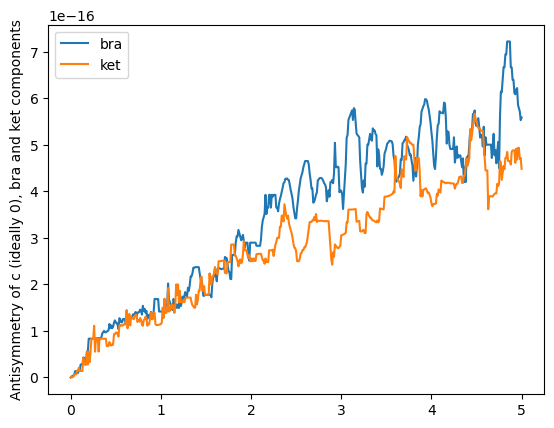

In [6]:
"""
Check c is antisymmetric
"""
def check_c2_antisymmetry(c2):
    bra_error=[]
    ket_error=[]
    for t in range(len(soln.t)):
        bra_error.append(np.max(np.abs(c2[:,:,:,:,t] + c2[:,:,:,:,t].swapaxes(0, 1))))
        ket_error.append(np.max(np.abs(c2[:,:,:,:,t] + c2[:,:,:,:,t].swapaxes(2, 3))))
    return np.array(bra_error), np.array(ket_error)

c4 = c_soln.reshape(2*P, 2*P, 2*P, 2*P, len(soln.t))
bra_err, ket_err = check_c2_antisymmetry(c4)

plt.plot(soln.t,bra_err,label='bra')
plt.plot(soln.t,ket_err,label='ket')
plt.ylabel('Antisymmetry of c (ideally 0), bra and ket components')
plt.legend()
plt.show()


(36, 36)


C:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


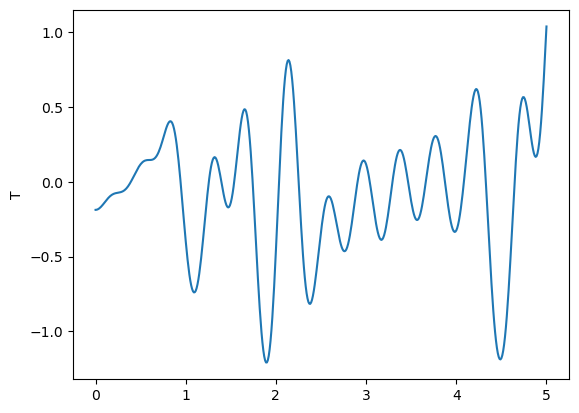

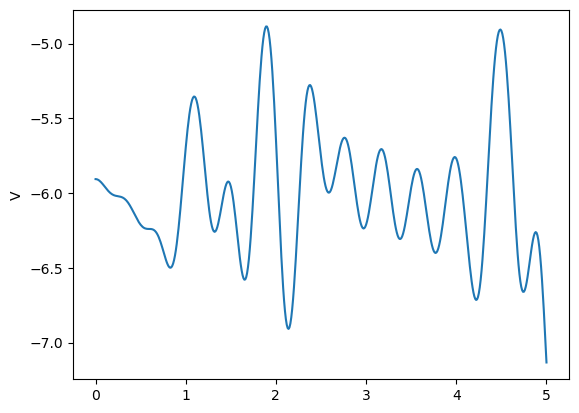

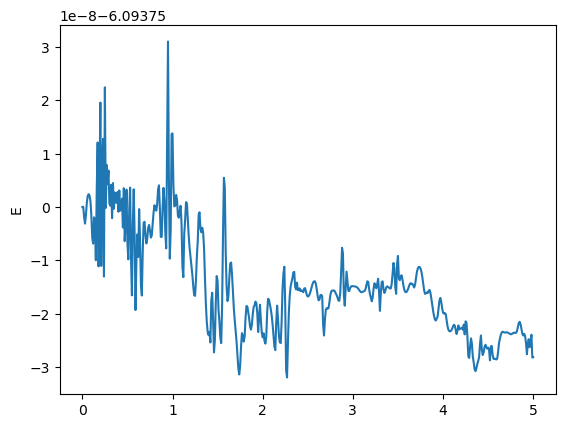

In [7]:
"""
Check energy conservation
"""
# print(Hh0())
print(Hv().shape)

# kinetic first (1body)
Ttot = np.trace( np.einsum("ijt,jk->ikt",rho_soln,Hh0()), axis1=0, axis2=1)
# now potential (2body)
Vtot = 0.5*np.trace( np.einsum("ijt,jk->ikt",rho2_soln,Hv()), axis1=0, axis2=1)
# print(f'V: {V[0].real:.3f},{V[100].real:.3f},{V[200].real:.3f}')
Etot = Ttot + Vtot

plt.plot(soln.t,Ttot)
plt.ylabel('T')
plt.show()
plt.plot(soln.t,Vtot)
plt.ylabel('V')
plt.show()

plt.plot(soln.t,Etot)
plt.ylabel('E')
plt.show()

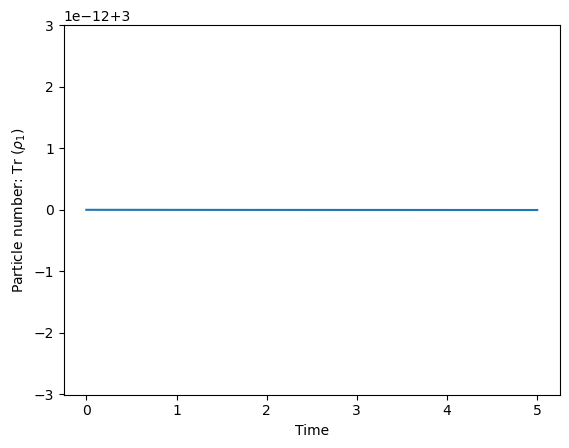

In [8]:
"""
particle number should be conserved
"""

plt.plot(soln.t,np.trace(rho_soln,axis1=0,axis2=1))
# plt.ylim(0,4)
plt.ylabel(r'Particle number: Tr $(\rho_1)$')
plt.xlabel('Time')
plt.show()

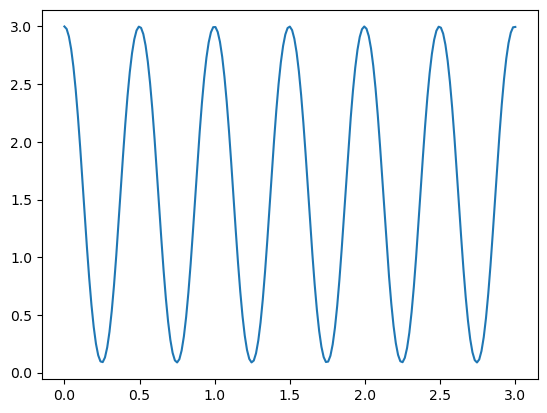

In [15]:
"""
Check number of particles in the bottom 
"""
mean, var, residual = lower_occupation(rho_soln, c_soln.reshape(2*P,2*P,2*P,2*P,-1), N=None)
plt.plot(soln.t,mean)
plt.show()


# plt.plot(soln.t,Ndown(rho_soln),label='bottom level')
# plt.plot(soln.t,Nup(rho_soln),label='top level')
# plt.legend()
# plt.show()

# # check how much of the state is in the HF stationary points 
# print(HFstat(rho_soln,np.arccos(eps/(V*P-V)),0)[0])
# print(HFstat(rho_soln,np.arccos(eps/(V*P-V)),np.pi)[0])
# print('') # this is the tdhf initial and constant 

# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),0),label='min1')
# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),np.pi),label='min2')
# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),0)+HFstat(rho_soln,np.arccos(eps/(V*P-V)),np.pi),label='sum') # they clearly have some overlap, bc >3
# plt.legend()
# plt.show()

In [46]:
'''
Do overlap of HF min with the full D, more 'proper' observable
'''

def Dtddm(rho,c):
    rhorhorho = np.einsum('ilt,jmt,knt->ijklmnt',rho,rho,rho)
    arhorhorho = antisym_3_full_t(rhorhorho)
    
    rhoc = np.einsum('ilt,jkmnt->ijklmnt', rho, c.reshape(2*P,2*P,2*P,2*P,len(soln.t)) ) #i1 j2 k3 l1 m2 n3 
    arhoc = antisym_3_full_t(rhoc)
    
    all3 = 6.0*arhorhorho + 9.0*arhoc # so that no repeated terms NEED THIS SO THAT TRACE IS CONSERVED!
    return all3

Dtddm_soln = Dtddm(rho_soln,c_soln)

(6, 6, 6, 6, 6, 6, 501)


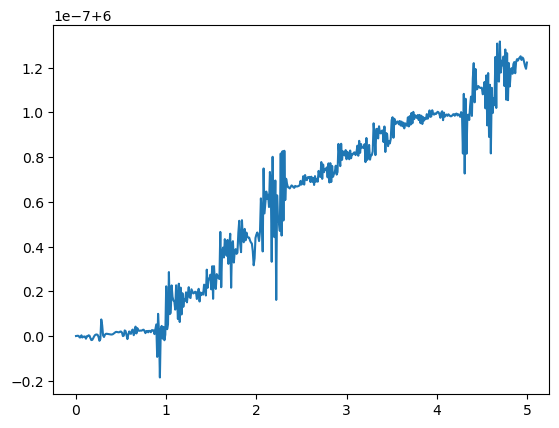

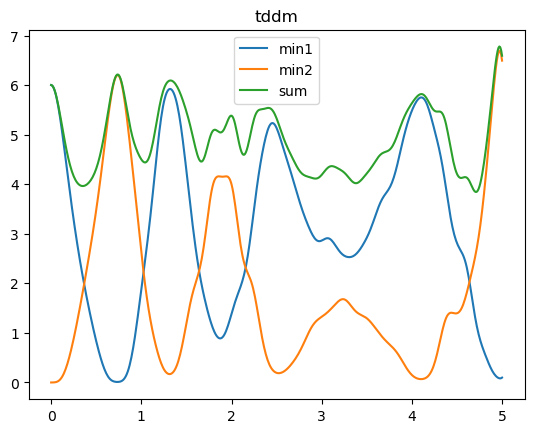

In [47]:
print(Dtddm_soln.shape)
plt.plot(soln.t,np.trace(Dtddm_soln.reshape(8*P**3,8*P**3,len(soln.t))))
plt.show()

# exHFstatD = HFstatD(Dtddm_soln,th,phi)
plt.plot(soln.t,HFstatD(Dtddm_soln,np.arccos(eps/(V*P-V)),0),label='min1')
plt.plot(soln.t,HFstatD(Dtddm_soln,np.arccos(eps/(V*P-V)),np.pi),label='min2')
plt.plot(soln.t,HFstatD(Dtddm_soln,np.arccos(eps/(V*P-V)),0)+HFstatD(Dtddm_soln,np.arccos(eps/(V*P-V)),np.pi),label='sum')
plt.title('tddm')
plt.legend()
plt.show()

In [33]:
# print(c_soln[:,:,0])
# print(c_soln[:,:,50])
# print(c_soln[:,:,-1])
print(np.max(c_soln))

(0.2499985148532373-5.43546254114636e-19j)


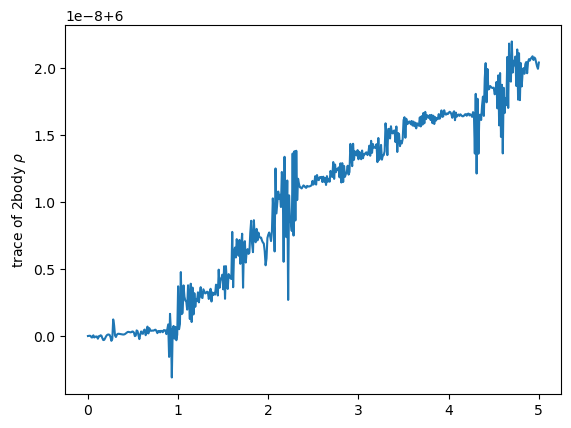

largest purity values (should <N): [(3.6226070304784064+3.6292702433793713e-12j), (3.5299733180574737+2.83675724382074e-12j), (3.43113086254527+2.1396196433943064e-12j)]
indices of these: [500, 499, 498]


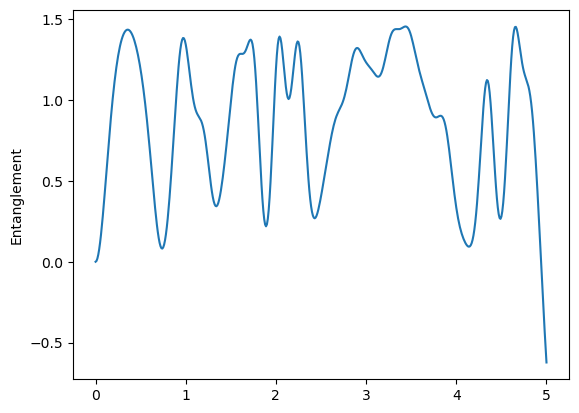

In [19]:
"""
Check purity
"""
# trace of twobody rho
plt.plot(soln.t,np.trace(rho2_soln,axis1=0,axis2=1))
plt.ylabel(r'trace of 2body $\rho$')
plt.show()

# purity of twobody rho
# THIS IS NOT HELPFUL! SHOULD BE 1BODY!
# purity = np.einsum('ijt,jit->t',rho2_soln,rho2_soln)

# purity of 1body rho
# print('indices of these:',largest_indices,'at time:',[soln.t[i] for i in largest_indices])
epower = Epower_funcs.Epower_rho(rho_soln,P)
plt.plot(soln.t,epower)
plt.ylabel(r'Entanglement')
plt.ylim(None,None)
plt.show()

In [20]:
"""
Check if the density matrix stays hermitian
"""
print('These should be 0:')
dI2 = rho2_soln - rho2_soln.conj().transpose(1,0,2)
print(dI2.real.max())
print(dI2.imag.max())

dI1 = rho_soln - rho_soln.conj().transpose(1,0,2)
print(dI1.real.max())
print(dI1.imag.max())

These should be 0:
2.5327517860773696e-12
2.2716019856646398e-12
1.0062506383690106e-12
1.708503344072045e-12


## Lipkin exact evolution ##

In [152]:
print((P-1)*V/eps)

8.0


In [22]:
t_list=np.linspace(0.0,5.0,501)

# all in bottom level
assert P==3
# p1 = np.array([1,0,0,0,0,0],dtype=complex)
# p2 = np.array([0,1,0,0,0,0],dtype=complex)
# p3 = np.array([0,0,1,0,0,0],dtype=complex)

# tdhf minimum 1
chi = (P-1)*V/eps
th = np.arccos(1/chi)
phi = 0
p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)

psiin = np.einsum('i,j,k->ijk',p1,p2,p3)
apsiin = 1/np.sqrt(6)*( psiin 
          -np.einsum('ijk->ikj',psiin)
          -np.einsum('ijk->jik',psiin)
          +np.einsum('ijk->jki',psiin)
          +np.einsum('ijk->kij',psiin)
          -np.einsum('ijk->kji',psiin)
         )
Din = np.einsum('ijk,lmn->ijklmn',apsiin,apsiin.conj() )
Din = Din.reshape(8*P**3,8*P**3)
print(Din.shape)

I2P = np.eye(2*P,dtype=complex)
H = ( np.einsum('il,jm,kn->ijklmn',Hh0(),I2P,I2P) 
     +np.einsum('ijlm,kn->ijklmn',Hv().reshape(2*P,2*P,2*P,2*P),I2P)    )
H = H.reshape(8*P**3,8*P**3)
Dout = []
for t in t_list:
    Dout.append( expm(-1j*H*t) @ Din @ expm(1j*H*t) )
    # print(( expm(-1j*H*t) @ Din @ expm(1j*H*t) ).shape)
Dout = np.array(Dout)
Dout = np.moveaxis(Dout,0,-1)
print(Dout.shape)

(216, 216)
(216, 216, 501)


In [23]:
print(Dout.shape)

(216, 216, 501)


In [48]:
"""
THESE OBSERVABLES ARE A BIT DODGY 
below is better

Check number of particles in the bottom 
"""
# rho_exact = 3*np.einsum( 'ijkljkt->ilt', Dout.reshape(2*P,2*P,2*P,2*P,2*P,2*P,len(t_list)) )
# plt.figure(figsize=(8,4))
# plt.plot(t_list,Ndown(rho_exact),label='Exact',color='mediumvioletred')
# plt.plot(soln.t,Ndown(rho_soln),label='TDDM',color='darkorange')
# plt.plot(soln.t,Ndown(rho_soln_tdhf),'b',label='Mean-field')
# plt.legend(loc=4,fontsize=11)
# plt.ylim(0,3.1)
# plt.xlabel('Time',fontsize=11)
# plt.ylabel(r'$\langle$Number in bottom$\rangle$',fontsize=11)
# # plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_Nbot.png',bbox_inches='tight',dpi=300)
# plt.show()


# ''' Check how much of the state is in the HF stationary points '''
# plt.figure(figsize=(8,4))
# plt.plot(t_list,HFstat(rho_exact,np.arccos(eps/(V*P-V)),0),label='Exact',color='mediumvioletred')
# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),0),label='TDDM',color='darkorange')
# plt.plot(soln_tdhf.t,HFstat(rho_soln_tdhf,np.arccos(eps/(V*P-V)),0),'b',label='Mean-field')
# plt.ylabel(r'$\langle$Number in HF ground 1$\rangle$',fontsize=11)
# plt.xlabel('Time',fontsize=11)
# plt.ylim(0,3.1)
# plt.legend(loc=4,fontsize=11)
# # plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_Nmin1.png',bbox_inches='tight',dpi=300)
# plt.show()

# plt.figure(figsize=(8,4))
# plt.plot(t_list,HFstat(rho_exact,np.arccos(eps/(V*P-V)),np.pi),'--',label='Exact',color='mediumvioletred')
# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),np.pi),'--',label='TDDM',color='darkorange')
# plt.plot(soln_tdhf.t,HFstat(rho_soln_tdhf,np.arccos(eps/(V*P-V)),np.pi),'b--',label='Mean-field')
# plt.ylabel(r'$\langle$Number in HF ground 2$\rangle$',fontsize=11)
# plt.xlabel('Time',fontsize=11)
# plt.ylim(0,3.1)
# plt.legend(loc=4,fontsize=11)
# # plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_Nmin2.png',bbox_inches='tight',dpi=300)
# plt.show()

'\nTHESE OBSERVABLES ARE A BIT DODGY \nbelow is better\n\nCheck number of particles in the bottom \n'

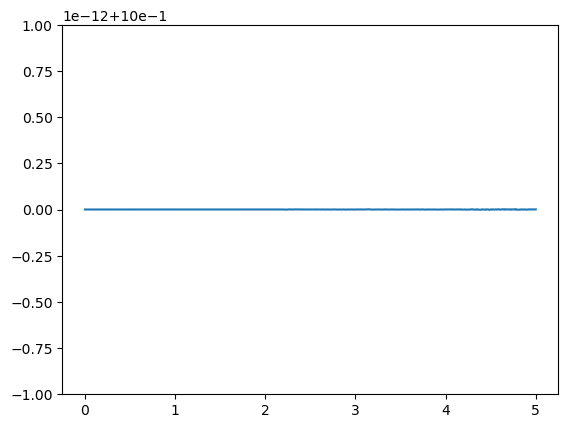

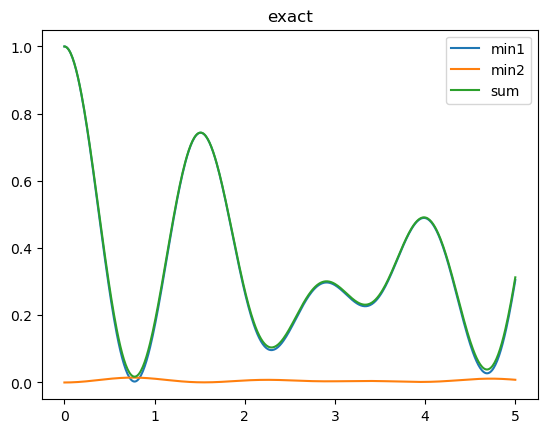

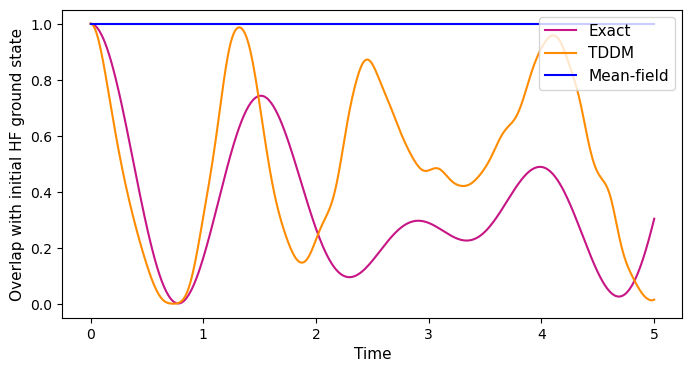

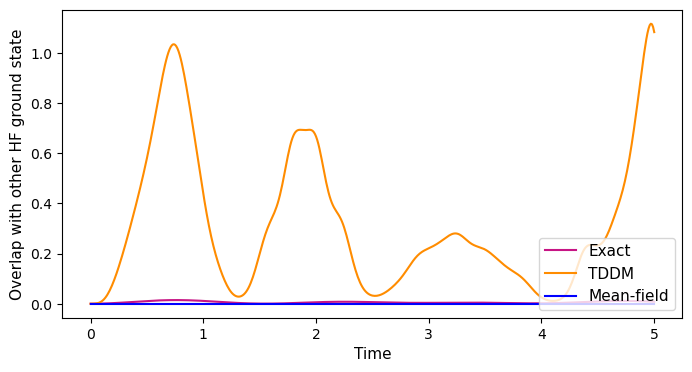

In [52]:
''' Check OVERLAP with HF stationary points '''
plt.plot(soln.t,np.trace(Dout))
plt.show()

# exHFstatD = HFstatD(Dtddm_soln,th,phi)
plt.plot(soln.t,HFstatD(Dout,np.arccos(eps/(V*P-V)),0),label='min1')
plt.plot(soln.t,HFstatD(Dout,np.arccos(eps/(V*P-V)),np.pi),label='min2')
plt.plot(soln.t,HFstatD(Dout,np.arccos(eps/(V*P-V)),0)+HFstatD(Dout,np.arccos(eps/(V*P-V)),np.pi),label='sum')
plt.title('exact')
plt.legend()
plt.show()



plt.figure(figsize=(8,4))
plt.plot(soln.t,HFstatD(Dout,np.arccos(eps/(V*P-V)),0),label='Exact',color='mediumvioletred')
plt.plot(soln.t,1/6*HFstatD(Dtddm_soln,np.arccos(eps/(V*P-V)),0),label='TDDM',color='darkorange')
plt.plot(soln_tdhf.t,HFstatD(rhorhorho_tdhf,np.arccos(eps/(V*P-V)),0),'b',label='Mean-field')
plt.ylabel('Overlap with initial HF ground state',fontsize=11)
plt.xlabel('Time',fontsize=11)
# plt.ylim(-0.05,1.05)
plt.legend(loc=1,fontsize=11)
# plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_overlapmin1.png',bbox_inches='tight',dpi=300)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(soln.t,HFstatD(Dout,np.arccos(eps/(V*P-V)),np.pi),label='Exact',color='mediumvioletred')
plt.plot(soln.t,1/6*HFstatD(Dtddm_soln,np.arccos(eps/(V*P-V)),np.pi),label='TDDM',color='darkorange')
plt.plot(soln_tdhf.t,HFstatD(rhorhorho_tdhf,np.arccos(eps/(V*P-V)),np.pi),'b',label='Mean-field')
plt.ylabel('Overlap with other HF ground state',fontsize=11)
plt.xlabel('Time',fontsize=11)
plt.legend(loc=4,fontsize=11)
plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_overlapmin2.png',bbox_inches='tight',dpi=300)
plt.show()

largest purity values (should <N): [(3.6226070304784064+3.6292702433793713e-12j), (3.5299733180574737+2.83675724382074e-12j), (3.43113086254527+2.1396196433943064e-12j)]
indices of these: [500, 499, 498]
largest purity values (should <N): [(3+0j), (2.999988993746763-1.371820777722231e-16j), (2.9999559753197937+7.757481583283122e-17j)]
indices of these: [0, 78, 156]
largest purity values (should <N): [(3.0000000000000133+0j), (3.000000000000013+0j), (3.000000000000013+0j)]
indices of these: [401, 397, 398]


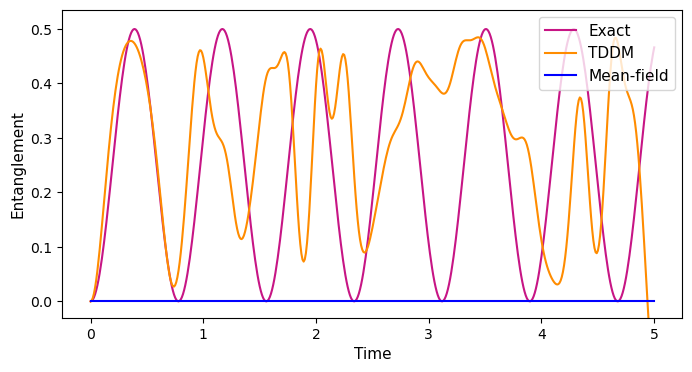

In [151]:
''' 
Check entanglement of these solutions 

FIX THE NORMALISATION 
'''

epower_soln = Epower_funcs.Epower_rho(rho_soln,P)/3
epower_exact = Epower_funcs.Epower_rho(rho_exact,P)/3
epower_soln_tdhf = Epower_funcs.Epower_rho(rho_soln_tdhf,P)/3

plt.figure(figsize=(8,4))
plt.plot(soln.t,epower_exact,label='Exact',color='mediumvioletred')
plt.plot(soln.t,epower_soln,label='TDDM',color='darkorange')
plt.plot(soln.t,epower_soln_tdhf,'b',label='Mean-field')
plt.ylabel(r'Entanglement',fontsize=11)
plt.xlabel('Time',fontsize=11)
plt.legend(loc=1,fontsize=11)
plt.ylim(-0.03,None)
# plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_entangle.png',bbox_inches='tight',dpi=300)
plt.show()

## TDHF calc ##

In [35]:
"""
Initial conditions
"""

"""
If rho0 is diagonal then we get a stationary solution of TDHF!!!

Slightly rotate the single-particle basis states
Then make a slater, and the corresp 1body rho
"""

# all in bottom level
# assert P==3
# p1 = np.array([1,0,0,0,0,0],dtype=complex)
# p2 = np.array([0,1,0,0,0,0],dtype=complex)
# p3 = np.array([0,0,1,0,0,0],dtype=complex)


# tdhf stat points
# minimum for V>0
th = np.arccos(eps/(V*P-V))
phi = 0 # n*pi 
# maximum for V>0
# th = np.arccos(-eps/(V*P-V))
# phi = np.pi/2 
p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)


# arbitrary non-stationary state
# de = 0.01
# p1 = np.array([np.cos(de),0,0,np.sin(de),0,0],dtype=complex) # only rotated the -1 state slightly into the +1 state
# p2 = np.array([0,1,0,0,0,0],dtype=complex)
# p3 = np.array([0,0,1,0,0,0],dtype=complex)


# for a Slater:
rho0 = np.outer(p1,p1.conj()) + np.outer(p2,p2.conj()) + np.outer(p3,p3.conj())

assert np.allclose(rho0@rho0,rho0)
assert np.allclose(np.trace(rho0),P)

y0 = rho0.ravel()

"""
Consistency checks for integration
""" 
assert rho0.shape == (2*P,2*P)
# assert c20.shape == (4,4)
assert y0.shape == (4*P**2,)

# Evaluate the RHS once to catch indexing errors.
test_derivative = TDHF(t=0.0,y=y0)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print('P =',P)
print("Initial state shape y0:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)

P = 3
Initial state shape y0: (36,)
Initial derivative shape: (36,)


In [36]:
''' Test initial derivative of rho, ie will it evolve? '''

drho0 = TDHF(0.0, rho0.ravel()).reshape(2*P, 2*P)
print("Maximum |drho/dt|:", np.max(np.abs(drho0)))
print("Frobenius norm of drho/dt:", np.linalg.norm(drho0))
print("drho/dt:")
print(np.round(drho0, 12))

Maximum |drho/dt|: 5.551115123125783e-16
Frobenius norm of drho/dt: 1.3597399555105183e-15
drho/dt:
[[0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.+0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.+0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.+0.j 0.-0.j 0.-0.j 0.-0.j]]


In [37]:
"""
And now we integrate
"""

t_list = np.linspace(0.0,5.0,501)
soln_tdhf = solve_ivp( 
    fun=TDHF,
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "RK45", # BDF  DOP853
    rtol=1e-9,
    atol=1e-11,
)

if not soln_tdhf.success:
    raise RuntimeError(
        f"Integration failed: {soln_tdhf.message}"
    )

In [40]:
rho_soln_tdhf = soln_tdhf.y.reshape(2*P,2*P,len(soln_tdhf.t))
rhorho_soln_tdhf = ( np.einsum("abt,cdt->acbdt", rho_soln_tdhf, rho_soln_tdhf)
                    - np.einsum("abt,cdt->acdbt", rho_soln_tdhf, rho_soln_tdhf) )
rhorho_soln_tdhf = rhorho_soln_tdhf.reshape(4*P**2,4*P**2,len(soln_tdhf.t))

rhorhorho_tdhf = antisym_3_full_t(np.einsum('ilt,jmt,knt->ijklmnt',rho_soln_tdhf,rho_soln_tdhf,rho_soln_tdhf))

print("rho_solution shape:", rho_soln_tdhf.shape)
print("rhorho_solution shape:", rhorho_soln_tdhf.shape)

rho_solution shape: (6, 6, 501)
rhorho_solution shape: (36, 36, 501)


(36, 36)


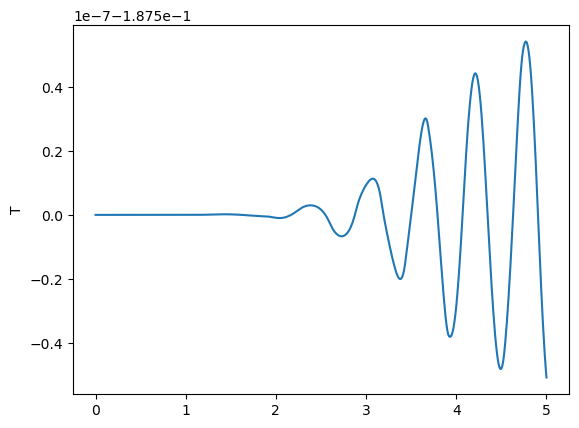

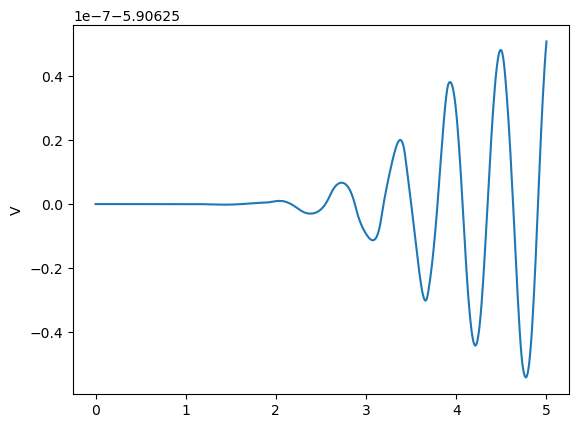

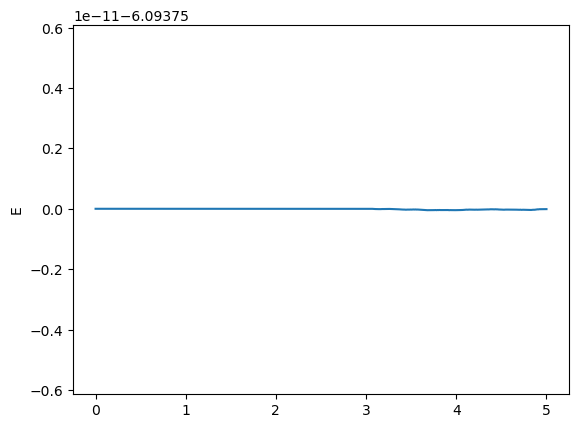

In [41]:
"""
Check energy conservation
"""
# print(Hh0())
print(Hv().shape)

# kinetic first (1body)
Ttot = np.trace( np.einsum("ijt,jk->ikt",rho_soln_tdhf,Hh0()), axis1=0, axis2=1)
# now potential (2body)
Vtot = 0.5*np.trace( np.einsum("ijt,jk->ikt",rhorho_soln_tdhf,Hv()), axis1=0, axis2=1)
# print(f'V: {V[0].real:.3f},{V[100].real:.3f},{V[200].real:.3f}')
Etot = Ttot + Vtot

plt.plot(soln_tdhf.t,Ttot)
plt.ylabel('T')
plt.show()
plt.plot(soln_tdhf.t,Vtot)
plt.ylabel('V')
plt.show()

plt.plot(soln_tdhf.t,Etot)
plt.ylabel('E')
plt.show()

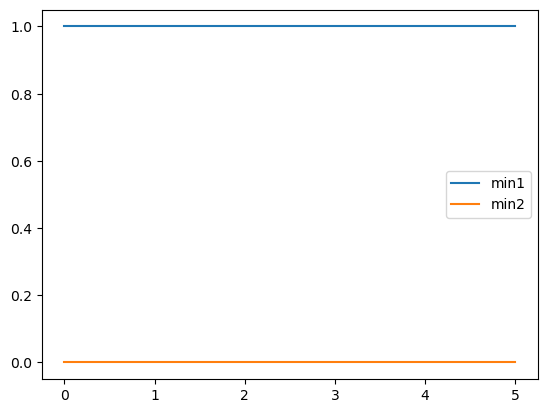

(3+0j)
(0.04687499999999986+7.941905977602169e-34j)


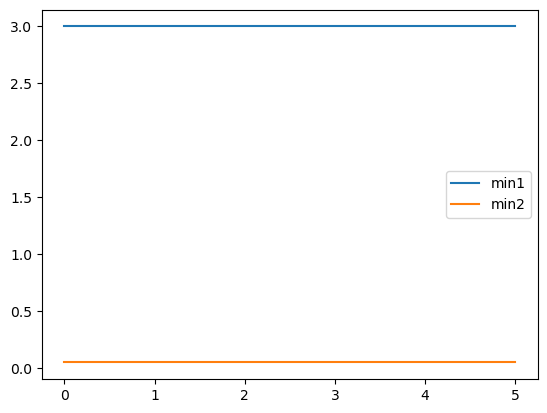

(1.6875+0j)


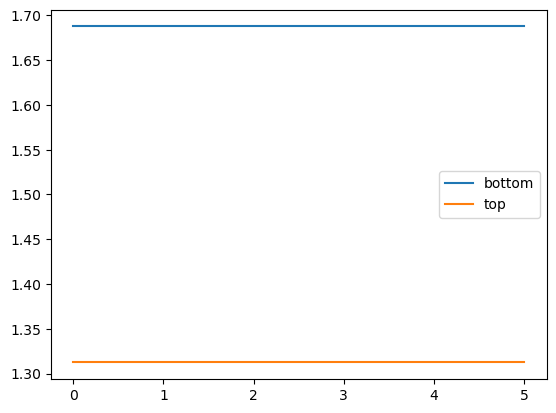

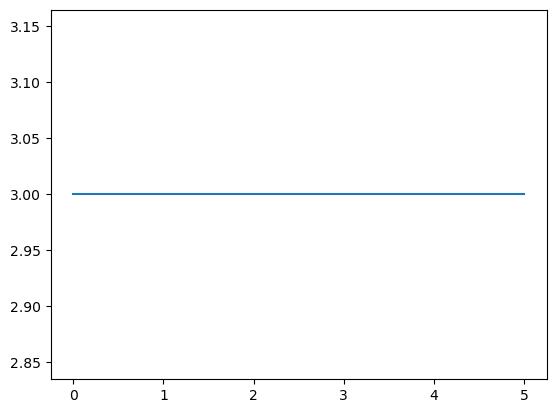

In [42]:
"""
Check number of particles in the bottom 

THIS IS STILL A BIT MESSY, NOT SURE WHICH HF MIN FUNCTION IS CORRECT 
"""

D_tdhf = antisym_3_full_t( np.einsum('ilt,jmt,knt->ijklmnt',rho_soln_tdhf,rho_soln_tdhf,rho_soln_tdhf) )
plt.plot(soln_tdhf.t, HFstatD(D_tdhf,np.arccos(eps/(V*P-V)),0),label='min1')
plt.plot(soln_tdhf.t, HFstatD(D_tdhf,np.arccos(eps/(V*P-V)),np.pi),label='min2')
plt.legend()
# plt.ylim(0,0.2)
plt.show()

print(HFstat(rho_soln_tdhf,np.arccos(eps/(V*P-V)),0)[0])
print(HFstat(rho_soln_tdhf,np.arccos(eps/(V*P-V)),np.pi)[0])
plt.plot(soln_tdhf.t,HFstat(rho_soln_tdhf,np.arccos(eps/(V*P-V)),0),label='min1')
plt.plot(soln_tdhf.t,HFstat(rho_soln_tdhf,np.arccos(eps/(V*P-V)),np.pi),label='min2')
plt.legend()
plt.show()

print(Ndown(rho_soln_tdhf)[0])
plt.plot(soln_tdhf.t,Ndown(rho_soln_tdhf),label='bottom')
plt.plot(soln_tdhf.t,Nup(rho_soln_tdhf),label='top')
# plt.ylim(0,3)
plt.legend()
plt.show()

# freqpeak, powerpeak = fourier_funcs.fourier(soln_tdhf.t,Ndown(rho_soln_tdhf),None,None,1)

plt.plot(soln_tdhf.t,Ndown(rho_soln_tdhf)+Nup(rho_soln_tdhf))
plt.show()

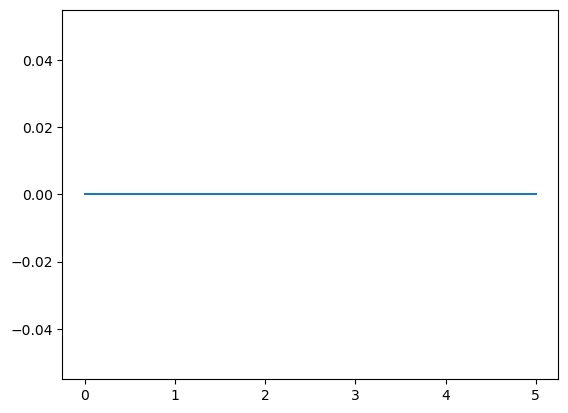

In [75]:
"""
check tdhf property rho^2 = rho
"""

def idempotency_error(rho):
    max = []
    for t in range(len(soln_tdhf.t)):
        max.append(np.max(np.abs(rho[:,:,t] @ rho[:,:,t] - rho[:,:,t])))
    return np.array(max)
plt.plot(soln_tdhf.t,idempotency_error(rho_soln_tdhf))
plt.show()

In [59]:
''' Check overlap of slaters '''

def slat(th,phi):
    p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
    p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
    p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)
    psiin = np.einsum('i,j,k->ijk',p1,p2,p3)
    # slat=psiin
    slat = 1/np.sqrt(6)*( psiin 
              -np.einsum('ijk->ikj',psiin)
              -np.einsum('ijk->jik',psiin)
              +np.einsum('ijk->jki',psiin)
              +np.einsum('ijk->kij',psiin)
              -np.einsum('ijk->kji',psiin)  )
    return slat.ravel()
print('orthog test for the 2 minima using slaters <1|2>:', slat(np.arccos(eps/(V*P-V)),0).conj().T @ slat(np.arccos(eps/(V*P-V)),np.pi) )

def makerho(th,phi):
    p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
    p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
    p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)
    rho0 = np.outer(p1,p1.conj()) + np.outer(p2,p2.conj()) + np.outer(p3,p3.conj())
    # trace is 3, good
    return rho0

def makeD(th,phi):
    D = antisym_3_full( np.einsum('il,jm,kn->ijklmn',makerho(th,phi),makerho(th,phi),makerho(th,phi)) )
    D = D.reshape(8*P**3,8*P**3)
    return D
print('orthog test for the 2 minima using sqrt(Tr[rho(1)rho(2)])', np.sqrt(np.trace(makeD(np.arccos(eps/(V*P-V)),0) @ makeD(np.arccos(eps/(V*P-V)),np.pi))))

orthog test for the 2 minima using slaters <1|2>: (0.0019531250000000867-2.511482693563889e-18j)
orthog test for the 2 minima using sqrt(Tr[rho(1)rho(2)]) (0.0019531249999928738+3.574525976795752e-31j)


## exact toy model 3 particles ##

H (8, 8)
501
(2, 2, 2, 2, 2, 2, 501)
rho12 (2, 2, 2, 2, 501)
(2, 2, 501)


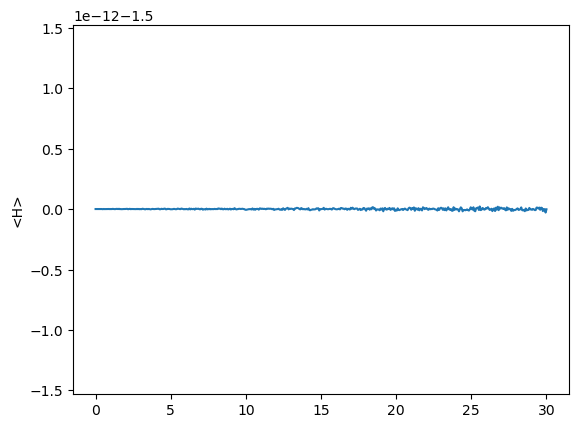

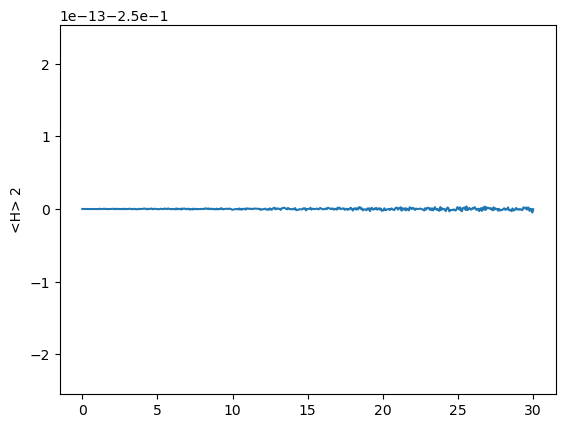

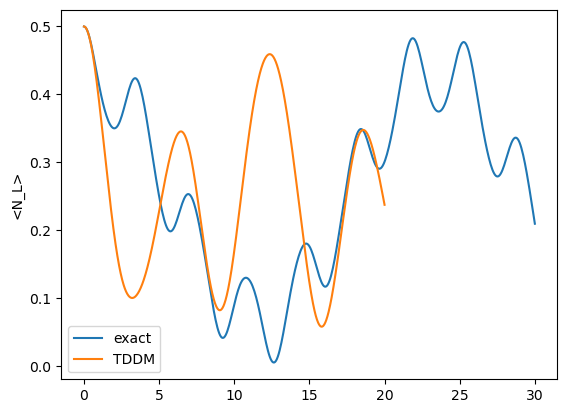

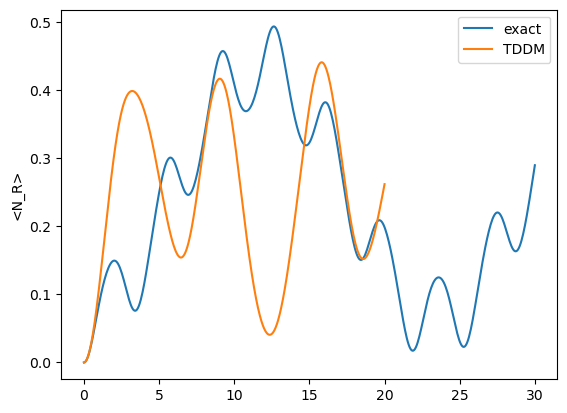

In [333]:
# set up the system and hamiltonian 
# mu = -0.8

h0 = a/2*np.array([[1,-1],
                   [-1,1]],dtype=complex)
v = np.array([[mu,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,0,mu]],dtype=complex)
I2 = np.eye(2,dtype=complex)
P23 = np.array([[1, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, 0, 0, 0, 0, 0],
                [0, 1, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 1, 0, 0, 0, 0],
                [0, 0, 0, 0, 1, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 1, 0],
                [0, 0, 0, 0, 0, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 1]], dtype=complex)
T = np.kron(np.kron(h0,I2),I2) + np.kron(np.kron(I2,h0),I2) + np.kron(np.kron(I2,I2),h0)
V = np.kron(v,I2) + P23@np.kron(v,I2)@P23.T.conj() + np.kron(I2,v)
H = T+V
print('H',H.shape)

# set up the state evolution
def rhoout(t_list,psiin):
    rhoout=[]
    for t in t_list:
        psiout = expm(-1j*H*t)@psiin
        rho = np.outer(psiout.T.conj(),psiout)
        rho = rho.reshape(2,2,2,2,2,2)
        rhoout.append(rho)
    rhoout = np.array(rhoout,dtype=complex)
    rhoout = np.moveaxis(rhoout, 0, -1)
    return rhoout

# calculate the state evolution
L1 = np.array([1,0],dtype=complex)
psiin = np.kron(np.kron(L1,L1),L1)
t_list = np.linspace(0.0,30.0,501)
print(len(t_list))
rhoout_exact = rhoout(t_list,psiin)
print(rhoout_exact.shape)

# make reduced density matrices
rho12_exact = (1)*np.trace(rhoout_exact,axis1=2,axis2=5) # coefficient depends on convention, 6 or 1
print('rho12',rho12_exact.shape)
rho1_exact = (1/2)*np.trace(   np.trace(rhoout_exact,axis1=2,axis2=5)   ,axis1=1,axis2=3) # coefficient depends on convention, 6/2 or 1/2
print(rho1_exact.shape)


# Look at energy conservation
# first using full rho and full H
rhoout_8x8 = rhoout_exact.reshape(8,8,len(t_list))
exE = np.trace( np.einsum('ijt,jk->ikt',rhoout_8x8,H) , axis1=0, axis2=1)
plt.plot(t_list,exE)
plt.ylabel('<H>')
plt.show()

# now using reduced densities and 1body, 2body components of H
exE2 = np.trace( np.einsum('ijt,jk->ikt',rho1_exact,h0) , axis1=0, axis2=1) + 0.5*np.trace( np.einsum('ijt,jk->ikt',rho12_exact.reshape(4,4,len(t_list)),v) , axis1=0, axis2=1)
plt.plot(t_list,exE2)
plt.ylabel('<H> 2')
plt.show()
# CLEARLY NEED THE FACTOR OF 0.5 INFRONT OF 2BODY V TERM SO THAT GET THE SAME E AND ALSO SO THAT E IS CONSERVED 



# Now look at number of particles in each well
plt.plot(t_list,NL(rho1_exact),label='exact')
plt.plot(soln.t,NL(rho_soln),label='TDDM')
plt.ylabel('<N_L>')
# plt.ylim(-0.5,3.5)
plt.legend()
plt.show()

plt.plot(t_list,NR(rho1_exact),label='exact')
plt.plot(soln.t,NR(rho_soln),label='TDDM')
plt.ylabel('<N_R>')
# plt.ylim(-0.5,3.5)
plt.legend()
plt.show()


# testing some properties of the 2body density, to inform code above. 
# first, the trace stays at 6:
    # plt.plot(t_list,np.trace(rho12_exact.reshape(4,4,len(t_list)),axis1=0,axis2=1))
    # plt.show()
# the norm starts at 6 but is not conserved, thats fine 
    # plt.plot(t_list,np.linalg.norm(rho12_exact.reshape(4,4,len(t_list)),axis=(0,1)))
    # plt.show()

# the 1body density trace stays at 3 as expected (particle number) 
    # plt.plot(t_list,np.trace(rho1_exact,axis1=0,axis2=1))
    # plt.show()